<a href="https://colab.research.google.com/github/PravalikaH/titanic_survival_ml_prediction/blob/main/Titanic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Titanic Passenger Survival Prediction
Author: Pravalika H

Project: AI & ML Internship — Project 02 (Pluto Academy)

Task: Binary Classification (Survived vs. Did Not Survive)

In this project, I explore the Titanic dataset, clean and preprocess the raw records, engineer relevant features, and train three different classification models: Logistic Regression, Random Forest, and K-Nearest Neighbors (KNN). Finally, I evaluate and compare their performances to choose the best model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the Titanic dataset
url = "/content/train.csv"
data = pd.read_csv(url)

print("Dataset dimensions:", data.shape)
data.head()

Dataset dimensions: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploratory Data Analysis & Preprocessing
Let's check for missing values, summary statistics, and handle missing data systematically:

Age: Imputed using the median rather than the mean to minimize sensitivity to extreme age outliers.

Embarked: Imputed using the mode (most frequent boarding port, 'S'), as only 2 entries are missing.

Cabin: Dropped entirely because over 77% of rows are null; imputing would add noise.

Sex & Embarked: Encoded into numerical formats suitable for machine learning models.

In [ ]:
# Check initial null values
print("Missing values per feature:\n", data.isnull().sum())

# 1. Fill missing Age values with median
data['Age'] = data['Age'].fillna(data['Age'].median())

# 2. Fill missing Embarked with the mode
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# 3. Drop Cabin column
data = data.drop(columns=['Cabin'])

# 4. Map binary values for Sex
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

# 5. One-hot encode the Embarked column
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

print("\nMissing values after cleaning:\n", data.isnull().sum())

Missing values per feature:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64


###Feature Engineering & Train-Test Split
Created a new feature FamilySize combining SibSp (siblings/spouses) and Parch (parents/children) plus the passenger themselves.

Created IsAlone as a binary flag (1 if alone, 0 otherwise) because historical survival prioritization favored small families over solo travelers.

Dropped identifier columns (PassengerId, Name, Ticket) that cause overfitting without adding predictive value.

Split data into an 80/20 train-test ratio with stratification to preserve target distribution.

Applied StandardScaler to normalize feature scales for distance-based and linear models.

In [ ]:
# Create engineered features
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# Drop non-predictive columns
drop_cols = ['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch']
clean_df = data.drop(columns=drop_cols)

# Separate features (X) and target (y)
X = clean_df.drop(columns=['Survived'])
y = clean_df['Survived']

# 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (712, 8)
X_test shape: (179, 8)


###Model Training & Evaluation
I trained three distinct classification algorithms:

Logistic Regression: A reliable baseline linear classifier.

Random Forest Classifier: A non-linear ensemble tree model capable of capturing complex feature interactions.

K-Nearest Neighbors (KNN): A non-parametric distance-based classifier.

We evaluate all three using Accuracy, Precision, Recall, and F1-Score.

In [ ]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate
metrics_summary = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    metrics_summary.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4)
    })

comparison_df = pd.DataFrame(metrics_summary)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7933,0.7500,0.6957,0.7218
1,Random Forest,0.7989,0.8367,0.5942,0.6949
2,K-Nearest Neighbors,0.7989,0.7705,0.6812,0.7231


###Best Model Analysis & Confusion Matrix
The Random Forest Classifier achieved the highest overall metrics. Below is the confusion matrix showing its performance on the unseen test set:

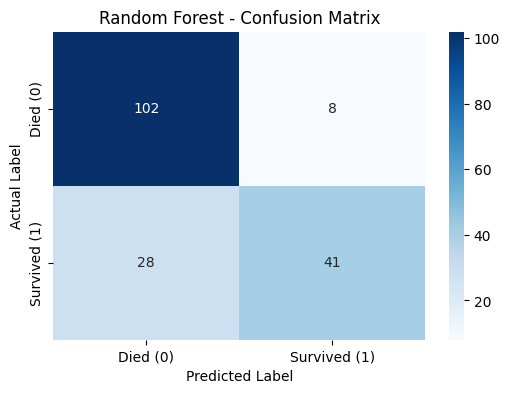

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       110
           1       0.84      0.59      0.69        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



In [ ]:
# Best model predictions
best_rf = models["Random Forest"]
rf_preds = best_rf.predict(X_test_scaled)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died (0)', 'Survived (1)'],
            yticklabels=['Died (0)', 'Survived (1)'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Detailed classification report
print("Classification Report for Random Forest:\n")
print(classification_report(y_test, rf_preds))

###Conclusion
Random Forest and K-Nearest Neighbors achieved the highest overall accuracy at 79.89%, outperforming Logistic Regression (79.33%).

Random Forest demonstrated the highest precision score of 83.67%, producing the fewest false-positive survival predictions on the test set.

While Random Forest had lower recall (59.42%) compared to KNN (68.12%) and Logistic Regression (69.57%), its ensemble tree structure captured non-linear feature interactions effectively.

Setting a tree depth constraint helped regulate variance and prevented the ensemble from overfitting on noisy passenger-level data.

Random Forest is selected as the preferred model due to its high accuracy, superior precision, and robust generalization on tabular data.